In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from myDataset import *
from MetricMethods import *
from ArchitectureMethods import *
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
print(os.getcwd())
os.chdir("..")
print(os.getcwd())

/user/HS401/ob00564/Documents/COM3001/JAFFE/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/JAFFE


In [3]:
train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers = 8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers = 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers = 8)

Train set length: 171
Test set length: 21
Validation set length: 21


In [4]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 24, '1': 23, '2': 26, '3': 25, '4': 25, '5': 24, '6': 24}
{'0': 3, '1': 3, '2': 3, '3': 3, '4': 3, '5': 3, '6': 3}
{'0': 3, '1': 3, '2': 3, '3': 3, '4': 3, '5': 3, '6': 3}


In [5]:
import torchvision.models as models

emotionTotal = 7
myModel = models.mobilenet_v2(weights = 'DEFAULT')
myModel.classifier = torch.nn.Linear(in_features=1280, out_features= 7)

# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.classifier.parameters():
    param.requires_grad = True

# # Unfreeze 16th, 17th, 18th layers
# for id in range(16,19):
#     for param in myModel.features[id].parameters():
#         param.requires_grad = True
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)


cuda


In [6]:
import copy
# @title Training Loop
from tqdm import tqdm

# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)

train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, "Transfer Learning/JAFFE MobileNetV2 copy.pth")
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')


100%|██████████| 11/11 [00:00<00:00, 14.84it/s]


Epoch 1/100, Training Loss: 1.9609, Validation Loss: 1.9398
Epoch 1/100, Training Acc: 14.46280991735537, Validation Accuracy: 9.375


100%|██████████| 11/11 [00:00<00:00, 27.29it/s]


Epoch 2/100, Training Loss: 1.9624, Validation Loss: 1.9538
Epoch 2/100, Training Acc: 12.5, Validation Accuracy: 12.5


100%|██████████| 11/11 [00:00<00:00, 26.82it/s]


...

Epoch 4/100, Training Loss: 1.9514, Validation Loss: 1.9875
Epoch 4/100, Training Acc: 14.152892561983471, Validation Accuracy: 6.25


100%|██████████| 11/11 [00:00<00:00, 28.26it/s]


Epoch 5/100, Training Loss: 1.9552, Validation Loss: 1.9952
Epoch 5/100, Training Acc: 16.942148760330582, Validation Accuracy: 6.25


100%|██████████| 11/11 [00:00<00:00, 25.67it/s]


Model saved successfully!
Test Loss: 1.9622, Test Accuracy: 28.57%


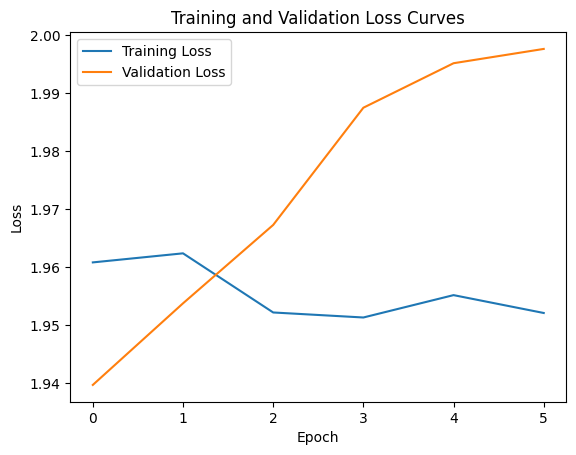

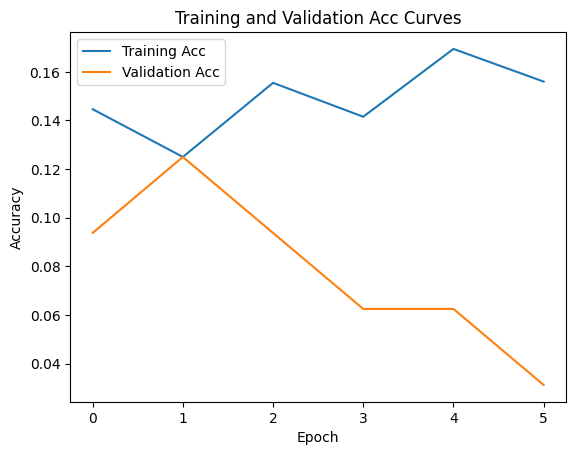

              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000         3
     Disgust     0.0000    0.0000    0.0000         3
        Fear     0.4000    0.6667    0.5000         3
   Happiness     0.2308    1.0000    0.3750         3
     Sadness     1.0000    0.3333    0.5000         3
    Surprise     0.0000    0.0000    0.0000         3
     Neurtal     0.0000    0.0000    0.0000         3

    accuracy                         0.2857        21
   macro avg     0.2330    0.2857    0.1964        21
weighted avg     0.2330    0.2857    0.1964        21



/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

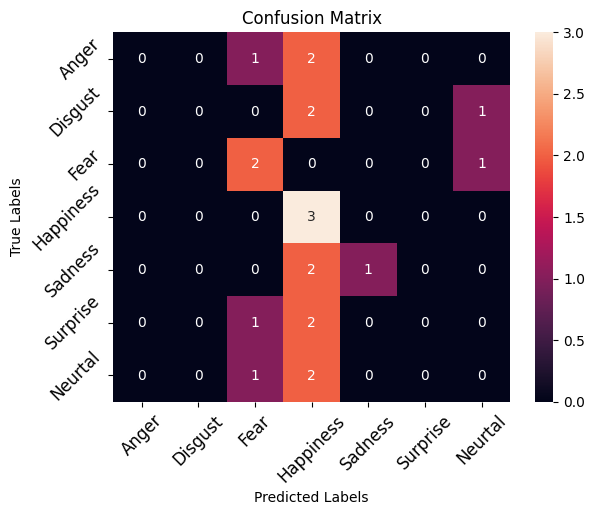

In [7]:
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred)